# Rejected Applications Analysis
LendingClub received 27.6 million rejected applications (2007–2018).
This notebook explores who was rejected, compares them to accepted applicants,
and reveals the full lending universe our model operates within.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# ── constants ──────────────────────────────────────────────────────────────
TOTAL_REJECTED   = 27_648_741   # exact row count
TOTAL_ACCEPTED   =  2_260_701   # full accepted CSV rows
TOTAL_FILTERED   =  1_348_092   # after status filtering (our model's universe)
TOTAL_ALL        = TOTAL_REJECTED + TOTAL_ACCEPTED
ACCEPT_RATE      = TOTAL_ACCEPTED / TOTAL_ALL
REJECT_RATE      = TOTAL_REJECTED / TOTAL_ALL

print(f'Total applications 2007-2018 : {TOTAL_ALL:>12,}')
print(f'  Accepted                     : {TOTAL_ACCEPTED:>12,}  ({ACCEPT_RATE:.1%})')
print(f'  Rejected                     : {TOTAL_REJECTED:>12,}  ({REJECT_RATE:.1%})')
print(f'  Used in our ML model         : {TOTAL_FILTERED:>12,}  (accepted & resolved loans only)')

Total applications 2007-2018 :   29,909,442
  Accepted                     :    2,260,701  (7.6%)
  Rejected                     :   27,648,741  (92.4%)
  Used in our ML model         :    1,348,092  (accepted & resolved loans only)


## 1. Load Rejected Loans Sample
The rejected CSV has 27.6M rows. We load a 500K sample for distribution analysis,
then use chunked reading for accurate time-trend and geographic counts.

In [2]:
# ── sample for distribution plots ──────────────────────────────────────────
rej = pd.read_csv(
    '../data/rejected_2007_to_2018Q4.csv',
    nrows=500_000,
    usecols=['Amount Requested', 'Application Date', 'Risk_Score',
             'Debt-To-Income Ratio', 'State', 'Employment Length']
)

# Parse DTI (comes as '10%', '25.5%', etc.)
rej['dti'] = pd.to_numeric(
    rej['Debt-To-Income Ratio'].str.replace('%', '').str.strip(),
    errors='coerce'
)
rej['year'] = pd.to_datetime(rej['Application Date'], errors='coerce').dt.year
rej['emp_clean'] = rej['Employment Length'].fillna('n/a')

# ── accepted loans (pre-preprocessing) ─────────────────────────────────────
acc = pd.read_parquet(
    '../data/loans_filtered.parquet',
    columns=['dti', 'annual_inc', 'loan_amnt', 'emp_length']
)

print('Rejected sample shape :', rej.shape)
print('Accepted (filtered)   :', acc.shape)
print()
print('Rejected columns:', list(rej.columns))
print('Risk_Score sample:', rej['Risk_Score'].describe())

Rejected sample shape : (500000, 9)
Accepted (filtered)   : (1348092, 4)

Rejected columns: ['Amount Requested', 'Application Date', 'Risk_Score', 'Debt-To-Income Ratio', 'State', 'Employment Length', 'dti', 'year', 'emp_clean']
Risk_Score sample: count    479294.000000
mean        584.546906
std         187.871457
min           0.000000
25%         557.000000
50%         643.000000
75%         688.000000
max         849.000000
Name: Risk_Score, dtype: float64


## 2. Scale Context — The Full Lending Universe

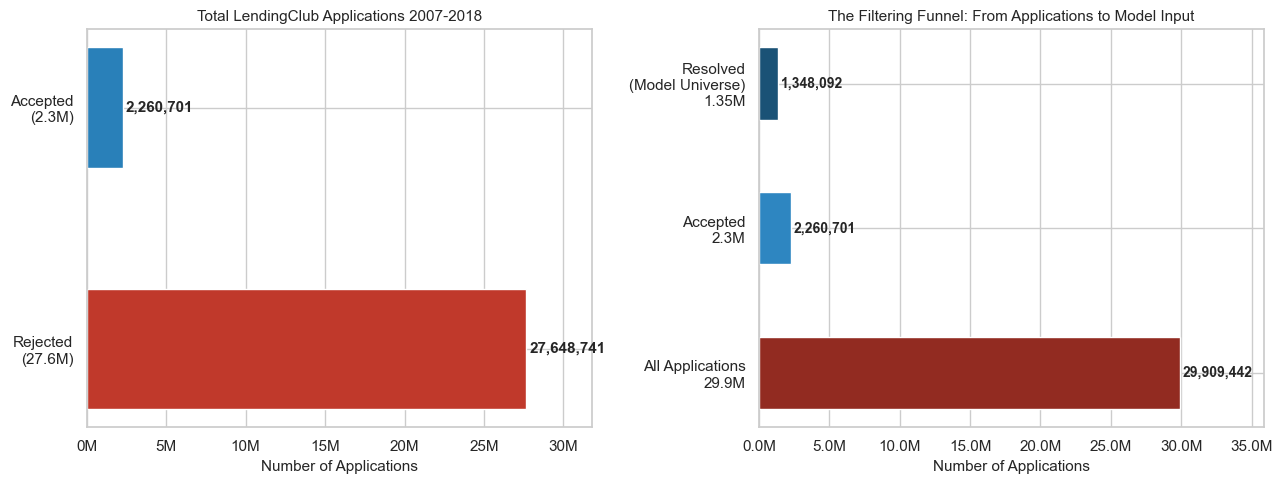

Our ML model sees only 4.5% of all applications LendingClub ever received.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── left: absolute counts ──────────────────────────────────────────────────
labels  = ['Rejected\n(27.6M)', 'Accepted\n(2.3M)']
values  = [TOTAL_REJECTED, TOTAL_ACCEPTED]
colors  = ['#C0392B', '#2980B9']
bars = axes[0].barh(labels, values, color=colors, edgecolor='white', height=0.5)
for bar, val in zip(bars, values):
    axes[0].text(val + 200_000, bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}', va='center', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Number of Applications', fontsize=11)
axes[0].set_title('Total LendingClub Applications 2007-2018', fontsize=11)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
axes[0].set_xlim(0, TOTAL_REJECTED * 1.15)

# ── right: three-tier funnel ───────────────────────────────────────────────
funnel_labels = ['All Applications\n29.9M', 'Accepted\n2.3M', 'Resolved\n(Model Universe)\n1.35M']
funnel_vals   = [TOTAL_ALL, TOTAL_ACCEPTED, TOTAL_FILTERED]
funnel_colors = ['#922B21', '#2E86C1', '#1A5276']
axes[1].barh(funnel_labels, funnel_vals, color=funnel_colors, edgecolor='white', height=0.5)
for i, (label, val) in enumerate(zip(funnel_labels, funnel_vals)):
    axes[1].text(val + 200_000, i, f'{val:,.0f}', va='center', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Number of Applications', fontsize=11)
axes[1].set_title('The Filtering Funnel: From Applications to Model Input', fontsize=11)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[1].set_xlim(0, TOTAL_ALL * 1.2)

plt.tight_layout()
plt.savefig('../data/rej_scale.png', dpi=100)
plt.show()

print(f'Our ML model sees only {TOTAL_FILTERED/TOTAL_ALL:.1%} of all applications LendingClub ever received.')

## 3. Debt-to-Income Ratio: Rejected vs Accepted

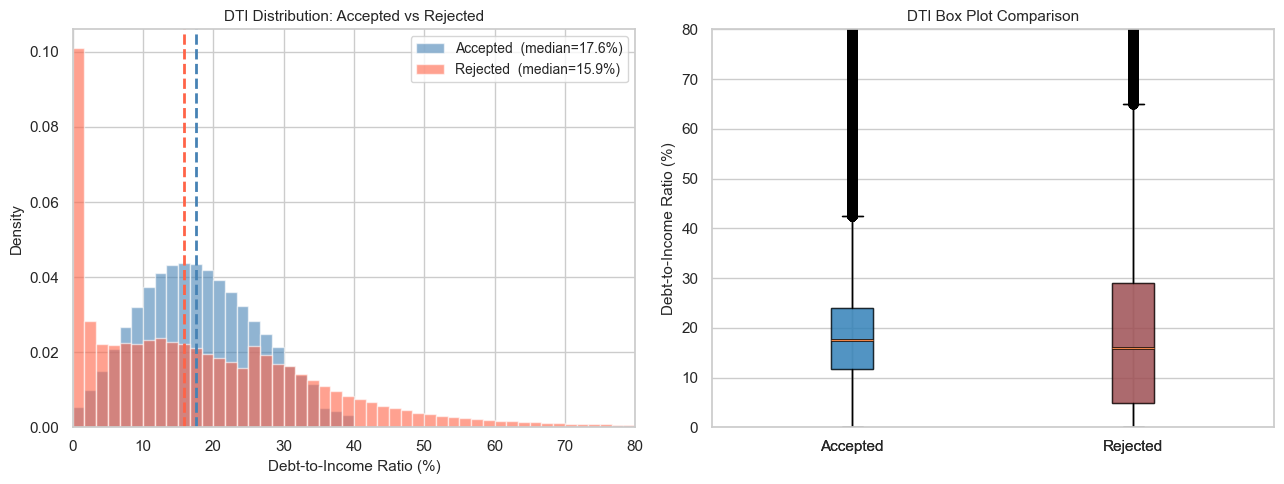

Accepted applicants  — DTI: median=17.6%, mean=18.2%
Rejected applicants  — DTI: median=15.9%, mean=19.3%
Difference in median DTI: -1.7 percentage points higher for rejected


In [4]:
rej_dti = rej['dti'].dropna()
rej_dti = rej_dti[(rej_dti >= 0) & (rej_dti <= 100)]
acc_dti = acc['dti'].dropna()
acc_dti = acc_dti[(acc_dti >= 0) & (acc_dti <= 100)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# KDE comparison
axes[0].hist(acc_dti, bins=60, alpha=0.6, color='steelblue', density=True, label=f'Accepted  (median={acc_dti.median():.1f}%)')
axes[0].hist(rej_dti, bins=60, alpha=0.6, color='tomato',    density=True, label=f'Rejected  (median={rej_dti.median():.1f}%)')
axes[0].axvline(acc_dti.median(), color='steelblue', linestyle='--', lw=2)
axes[0].axvline(rej_dti.median(), color='tomato',    linestyle='--', lw=2)
axes[0].set_xlabel('Debt-to-Income Ratio (%)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('DTI Distribution: Accepted vs Rejected', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_xlim(0, 80)

# Box comparison
axes[1].boxplot([acc_dti, rej_dti], labels=['Accepted', 'Rejected'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='black', linewidth=2))
bplot = axes[1].boxplot([acc_dti, rej_dti], labels=['Accepted', 'Rejected'], patch_artist=True)
bplot['boxes'][0].set_facecolor('#2980B9')
bplot['boxes'][0].set_alpha(0.6)
bplot['boxes'][1].set_facecolor('#C0392B')
bplot['boxes'][1].set_alpha(0.6)
axes[1].set_ylabel('Debt-to-Income Ratio (%)', fontsize=11)
axes[1].set_title('DTI Box Plot Comparison', fontsize=11)
axes[1].set_ylim(0, 80)

plt.tight_layout()
plt.savefig('../data/rej_dti.png', dpi=100)
plt.show()

print(f'Accepted applicants  — DTI: median={acc_dti.median():.1f}%, mean={acc_dti.mean():.1f}%')
print(f'Rejected applicants  — DTI: median={rej_dti.median():.1f}%, mean={rej_dti.mean():.1f}%')
print(f'Difference in median DTI: {rej_dti.median() - acc_dti.median():.1f} percentage points higher for rejected')

## 4. Risk Score (FICO) Distribution
Rejected applicants have a `Risk_Score` column (a credit/FICO-like score).
The accepted dataset doesn't have this field, so we analyse rejected only.
FICO bands: <580 Very Poor, 580-669 Fair, 670-739 Good, 740-799 Very Good, 800+ Exceptional.

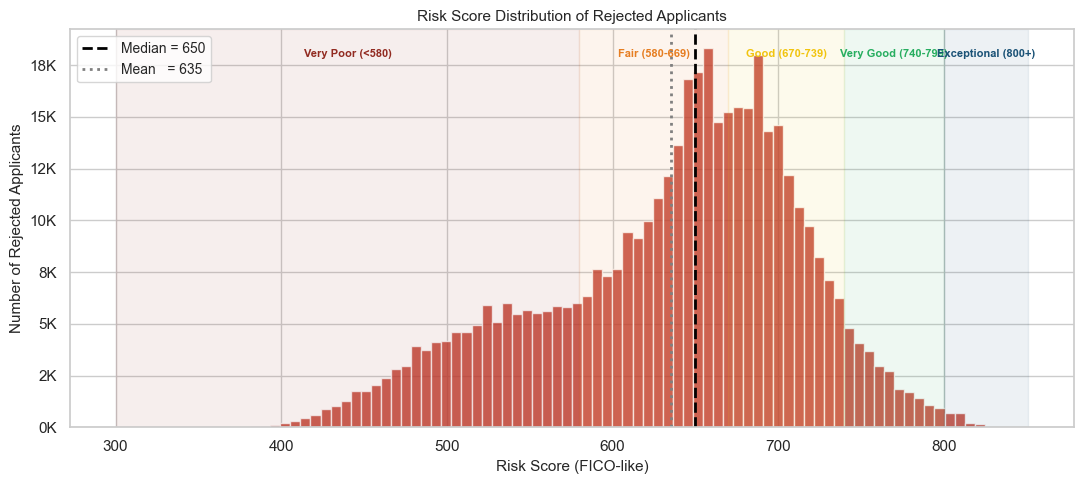

Risk Score stats for rejected applicants:
  Median : 650
  Mean   : 635.0
  Std    : 79.3
  Min    : 363   Max: 849

FICO Band breakdown:
  Very Poor (<580)              : 23.5%
  Fair (580-669)                : 38.7%
  Good (670-739)                : 31.6%
  Very Good (740-799)           : 5.7%
  Exceptional (800+)            : 0.4%


In [5]:
risk = rej['Risk_Score'].dropna()
risk = risk[(risk >= 300) & (risk <= 850)]

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(risk, bins=80, color='#C0392B', alpha=0.8, edgecolor='white')

# FICO band shading
bands = [
    (300, 580, '#922B21', 'Very Poor (<580)'),
    (580, 670, '#E67E22', 'Fair (580-669)'),
    (670, 740, '#F1C40F', 'Good (670-739)'),
    (740, 800, '#27AE60', 'Very Good (740-799)'),
    (800, 851, '#1A5276', 'Exceptional (800+)'),
]
ymax = ax.get_ylim()[1]
for lo, hi, col, label in bands:
    ax.axvspan(lo, hi, alpha=0.08, color=col)
    ax.text((lo+hi)/2, ymax * 0.95, label, ha='center', va='top', fontsize=8, color=col, fontweight='bold')

ax.axvline(risk.median(), color='black', linestyle='--', lw=2, label=f'Median = {risk.median():.0f}')
ax.axvline(risk.mean(),   color='gray',  linestyle=':',  lw=2, label=f'Mean   = {risk.mean():.0f}')
ax.set_xlabel('Risk Score (FICO-like)', fontsize=11)
ax.set_ylabel('Number of Rejected Applicants', fontsize=11)
ax.set_title('Risk Score Distribution of Rejected Applicants', fontsize=11)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('../data/rej_risk.png', dpi=100)
plt.show()

print(f'Risk Score stats for rejected applicants:')
print(f'  Median : {risk.median():.0f}')
print(f'  Mean   : {risk.mean():.1f}')
print(f'  Std    : {risk.std():.1f}')
print(f'  Min    : {risk.min():.0f}   Max: {risk.max():.0f}')
print()
print('FICO Band breakdown:')
for lo, hi, _, label in bands:
    pct = ((risk >= lo) & (risk < hi)).mean()
    print(f'  {label:30s}: {pct:.1%}')

## 5. Loan Amount: Rejected vs Accepted

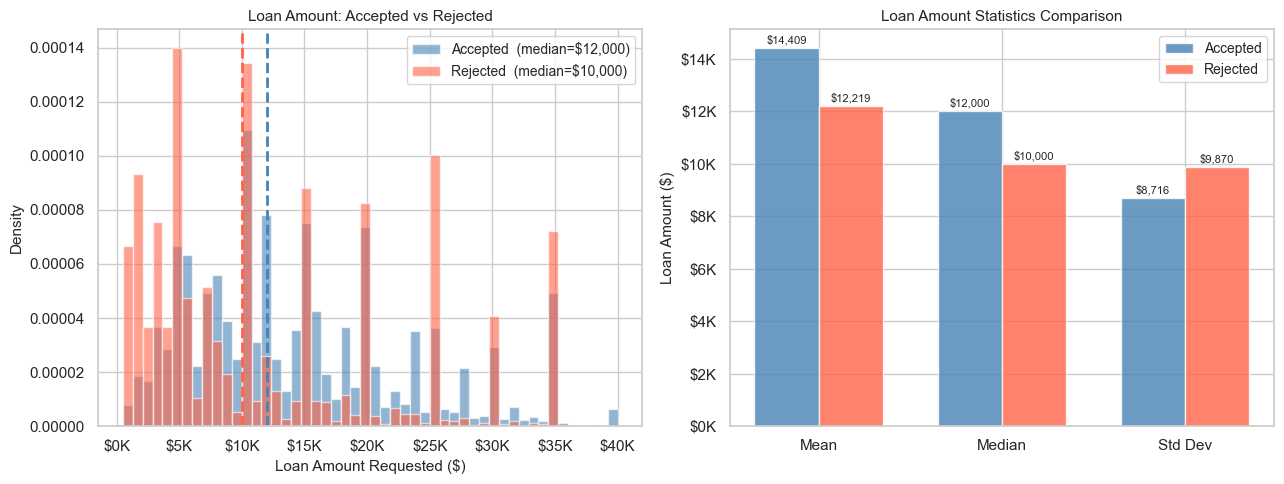

Accepted  mean=$14,409  median=$12,000
Rejected  mean=$12,219  median=$10,000


In [6]:
rej_amt = rej['Amount Requested'].dropna()
rej_amt = rej_amt[(rej_amt > 0) & (rej_amt <= 40_000)]
acc_amt = acc['loan_amnt'].dropna()
acc_amt = acc_amt[(acc_amt > 0) & (acc_amt <= 40_000)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(acc_amt, bins=50, alpha=0.6, color='steelblue', density=True,
             label=f'Accepted  (median=${acc_amt.median():,.0f})')
axes[0].hist(rej_amt, bins=50, alpha=0.6, color='tomato',    density=True,
             label=f'Rejected  (median=${rej_amt.median():,.0f})')
axes[0].axvline(acc_amt.median(), color='steelblue', linestyle='--', lw=2)
axes[0].axvline(rej_amt.median(), color='tomato',    linestyle='--', lw=2)
axes[0].set_xlabel('Loan Amount Requested ($)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('Loan Amount: Accepted vs Rejected', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Mean bar chart comparison
summary_data = {
    'Accepted': [acc_amt.mean(), acc_amt.median(), acc_amt.std()],
    'Rejected': [rej_amt.mean(), rej_amt.median(), rej_amt.std()],
}
metrics = ['Mean', 'Median', 'Std Dev']
x = np.arange(len(metrics))
width = 0.35
axes[1].bar(x - width/2, summary_data['Accepted'], width, label='Accepted', color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, summary_data['Rejected'], width, label='Rejected', color='tomato',    alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_ylabel('Loan Amount ($)', fontsize=11)
axes[1].set_title('Loan Amount Statistics Comparison', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../data/rej_amount.png', dpi=100)
plt.show()

print(f'Accepted  mean=${acc_amt.mean():,.0f}  median=${acc_amt.median():,.0f}')
print(f'Rejected  mean=${rej_amt.mean():,.0f}  median=${rej_amt.median():,.0f}')

## 6. Employment Length: Rejected vs Accepted

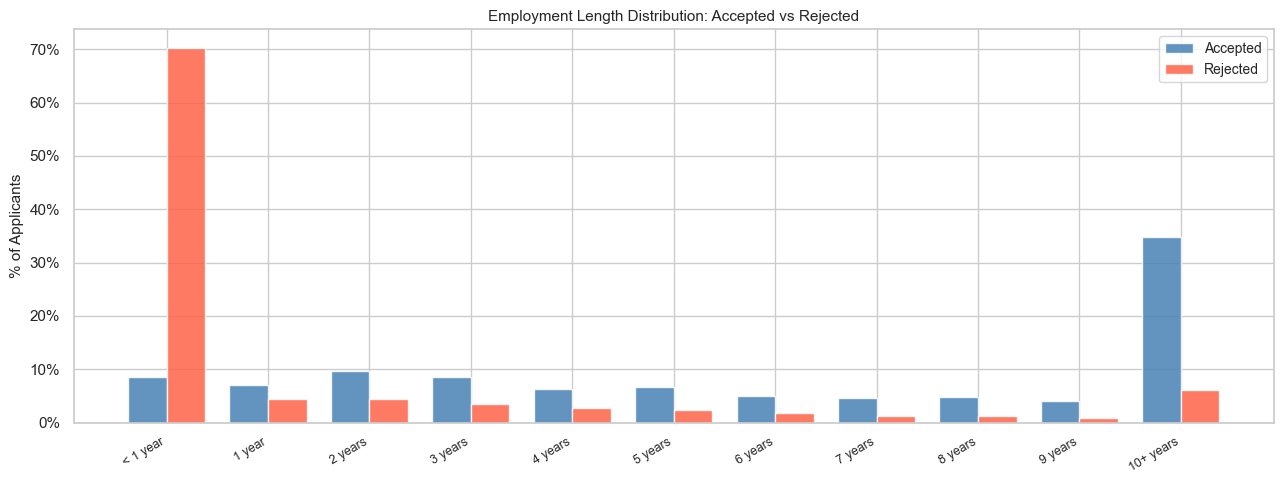

Employment distribution comparison (%):
           Accepted  Rejected  Diff (Rej - Acc)
< 1 year        8.5      70.2              61.7
1 year          7.0       4.4              -2.6
2 years         9.6       4.5              -5.1
3 years         8.5       3.5              -5.0
4 years         6.4       2.7              -3.7
5 years         6.6       2.4              -4.3
6 years         5.0       1.8              -3.2
7 years         4.7       1.3              -3.4
8 years         4.8       1.2              -3.6
9 years         4.0       0.9              -3.1
10+ years      34.9       6.1             -28.8


In [7]:
EMP_ORDER = ['< 1 year','1 year','2 years','3 years','4 years',
             '5 years','6 years','7 years','8 years','9 years','10+ years']

rej_emp = rej['emp_clean'].value_counts(normalize=True)
acc_emp = acc['emp_length'].value_counts(normalize=True)

# Align to same order
rej_pct = pd.Series({k: rej_emp.get(k, 0) for k in EMP_ORDER})
acc_pct = pd.Series({k: acc_emp.get(k, 0) for k in EMP_ORDER})

x     = np.arange(len(EMP_ORDER))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width/2, acc_pct.values * 100, width, label='Accepted', color='steelblue', alpha=0.85)
ax.bar(x + width/2, rej_pct.values * 100, width, label='Rejected', color='tomato',    alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(EMP_ORDER, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('% of Applicants', fontsize=11)
ax.set_title('Employment Length Distribution: Accepted vs Rejected', fontsize=11)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig('../data/rej_emp.png', dpi=100)
plt.show()

print('Employment distribution comparison (%):')
comp_df = pd.DataFrame({'Accepted': acc_pct * 100, 'Rejected': rej_pct * 100})
comp_df['Diff (Rej - Acc)'] = (comp_df['Rejected'] - comp_df['Accepted']).round(1)
print(comp_df.round(1).to_string())

## 7. Time Trends: Applications Per Year
Uses chunked reading over the full 27.6M rows to get accurate yearly counts.

Reading full rejected file in chunks (this may take 1-2 minutes)...
Done. Total counted: 27,648,741


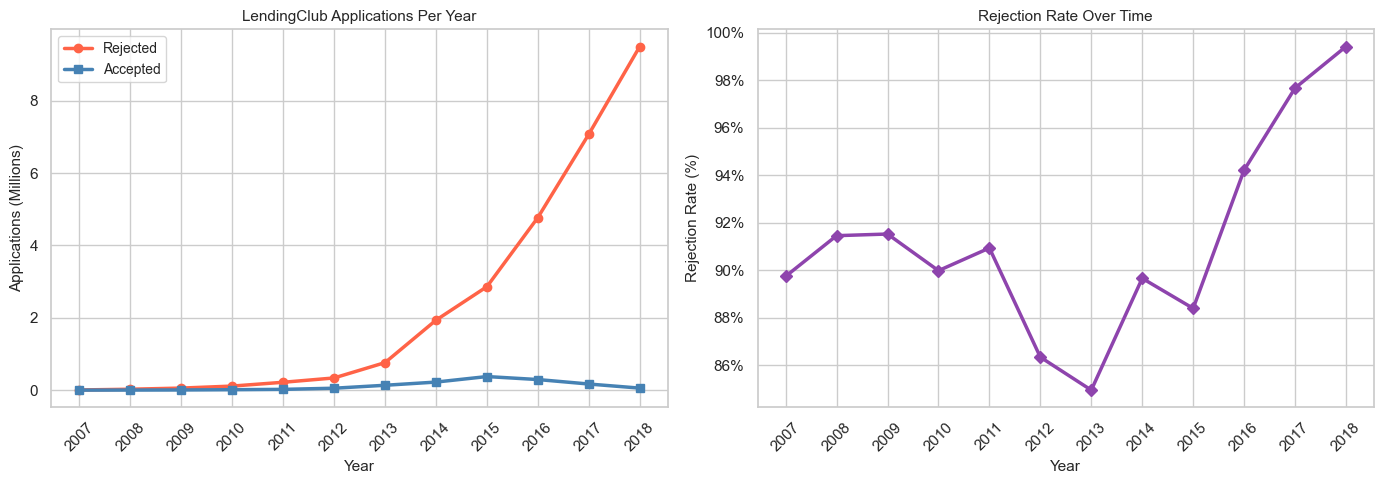

Rejected applications by year:
  2007:      5,274
  2008:     25,596
  2009:     56,991
  2010:    112,561
  2011:    217,792
  2012:    337,277
  2013:    760,942
  2014:  1,933,700
  2015:  2,859,379
  2016:  4,769,874
  2017:  7,072,573
  2018:  9,496,782


In [8]:
from collections import Counter

print('Reading full rejected file in chunks (this may take 1-2 minutes)...')
year_counter = Counter()

for chunk in pd.read_csv(
    '../data/rejected_2007_to_2018Q4.csv',
    chunksize=1_000_000,
    usecols=['Application Date']
):
    years = pd.to_datetime(chunk['Application Date'], errors='coerce').dt.year
    year_counter.update(years.dropna().astype(int).tolist())

print(f'Done. Total counted: {sum(year_counter.values()):,}')

rej_by_year = pd.Series(dict(sorted(year_counter.items())))
rej_by_year = rej_by_year[(rej_by_year.index >= 2007) & (rej_by_year.index <= 2018)]

# Accepted by year (from loans_filtered)
acc_full = pd.read_parquet('../data/loans_filtered.parquet', columns=['issue_d'])
acc_full['year'] = pd.to_datetime(acc_full['issue_d'], format='%b-%Y', errors='coerce').dt.year
acc_by_year = acc_full['year'].value_counts().sort_index()
acc_by_year = acc_by_year[(acc_by_year.index >= 2007) & (acc_by_year.index <= 2018)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute counts
axes[0].plot(rej_by_year.index, rej_by_year.values / 1e6, 'o-', color='tomato',    lw=2.5, label='Rejected')
axes[0].plot(acc_by_year.index, acc_by_year.values / 1e6, 's-', color='steelblue', lw=2.5, label='Accepted')
axes[0].set_xlabel('Year', fontsize=11)
axes[0].set_ylabel('Applications (Millions)', fontsize=11)
axes[0].set_title('LendingClub Applications Per Year', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_xticks(range(2007, 2019))
axes[0].tick_params(axis='x', rotation=45)

# Rejection rate per year
years_common = sorted(set(rej_by_year.index) & set(acc_by_year.index))
rej_rate_yr  = [rej_by_year[y] / (rej_by_year[y] + acc_by_year.get(y, 0)) for y in years_common]
axes[1].plot(years_common, [r * 100 for r in rej_rate_yr], 'D-', color='#8E44AD', lw=2.5)
axes[1].set_xlabel('Year', fontsize=11)
axes[1].set_ylabel('Rejection Rate (%)', fontsize=11)
axes[1].set_title('Rejection Rate Over Time', fontsize=11)
axes[1].set_xticks(range(2007, 2019))
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig('../data/rej_time.png', dpi=100)
plt.show()

print('Rejected applications by year:')
for y in rej_by_year.index:
    print(f'  {y}: {rej_by_year[y]:>10,}')

## 8. Geographic Analysis — Rejection Patterns by State

Reading state data in chunks...
Done. States found: 51


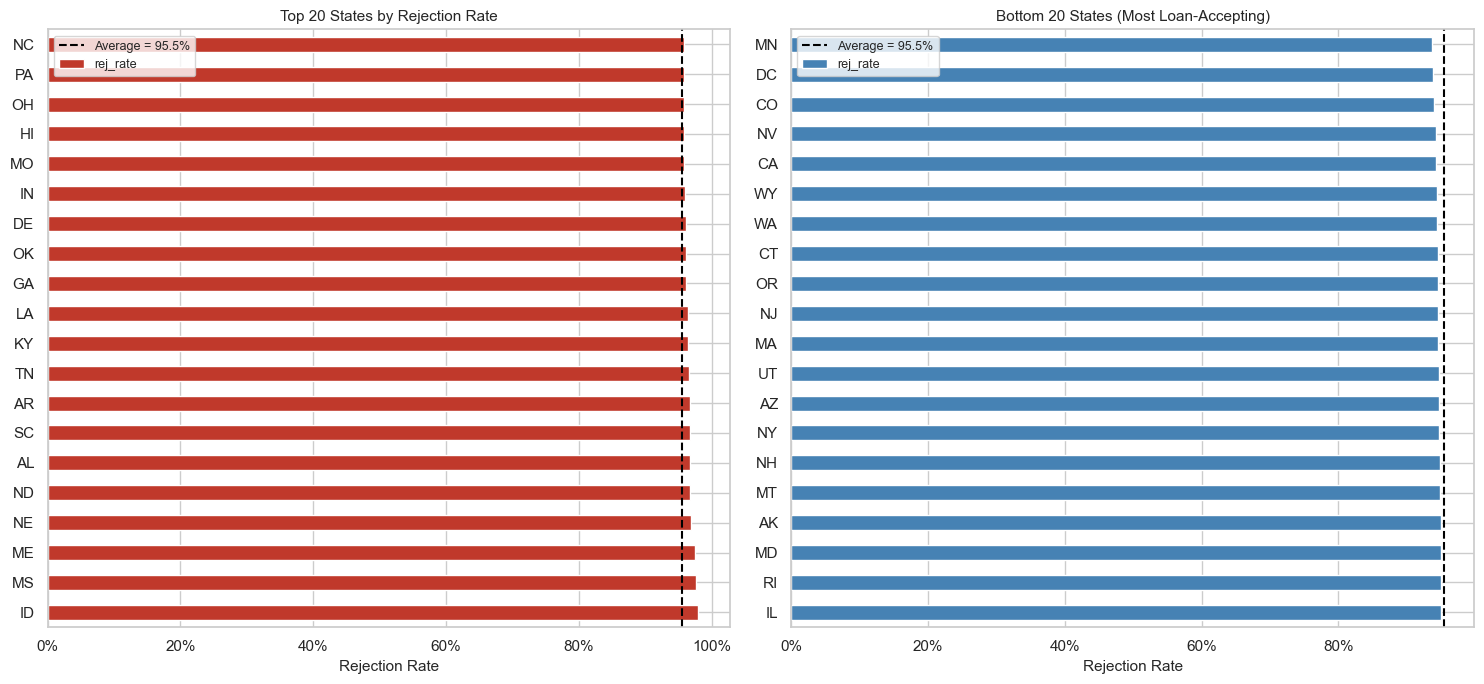

Overall rejection rate: 95.5%
Highest rejection state: ID (97.9%)
Lowest rejection state:  MN (93.7%)


In [9]:
print('Reading state data in chunks...')
state_counter = Counter()

for chunk in pd.read_csv(
    '../data/rejected_2007_to_2018Q4.csv',
    chunksize=1_000_000,
    usecols=['State']
):
    state_counter.update(chunk['State'].dropna().tolist())

print(f'Done. States found: {len(state_counter)}')

# Accepted by state
acc_state_df = pd.read_parquet('../data/loans_filtered.parquet', columns=['addr_state'])
acc_state = acc_state_df['addr_state'].value_counts()

# Build comparison table
rej_state = pd.Series(dict(state_counter))
all_states = sorted(set(rej_state.index) | set(acc_state.index))
state_df = pd.DataFrame({
    'rejected': rej_state.reindex(all_states, fill_value=0),
    'accepted': acc_state.reindex(all_states, fill_value=0)
})
state_df['total']    = state_df['rejected'] + state_df['accepted']
state_df['rej_rate'] = state_df['rejected'] / state_df['total']
state_df = state_df[state_df['total'] > 5000].sort_values('rej_rate', ascending=False)

top20 = state_df.head(20)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Top 20 states by rejection rate
colors = ['#C0392B' if r > 0.95 else '#E67E22' if r > 0.90 else '#2980B9'
          for r in top20['rej_rate']]
top20['rej_rate'].plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_xlabel('Rejection Rate', fontsize=11)
axes[0].set_title('Top 20 States by Rejection Rate', fontsize=11)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[0].axvline(state_df['rej_rate'].mean(), color='black', linestyle='--',
                label=f'Average = {state_df["rej_rate"].mean():.1%}')
axes[0].legend(fontsize=9)

# Bottom 20 by rejection rate (most accepting states)
bot20 = state_df.tail(20)
bot20['rej_rate'].plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_xlabel('Rejection Rate', fontsize=11)
axes[1].set_title('Bottom 20 States (Most Loan-Accepting)', fontsize=11)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1].axvline(state_df['rej_rate'].mean(), color='black', linestyle='--',
                label=f'Average = {state_df["rej_rate"].mean():.1%}')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/rej_geo.png', dpi=100)
plt.show()

print(f'Overall rejection rate: {state_df["rej_rate"].mean():.1%}')
print(f'Highest rejection state: {state_df.index[0]} ({state_df["rej_rate"].iloc[0]:.1%})')
print(f'Lowest rejection state:  {state_df.index[-1]} ({state_df["rej_rate"].iloc[-1]:.1%})')

## 9. Summary & Key Insights

In [10]:
print('=' * 60)
print('      REJECTED LOANS ANALYSIS — KEY INSIGHTS')
print('=' * 60)
print(f'''
SCALE:
  LendingClub received {TOTAL_ALL:,.0f} total applications (2007-2018).
  {TOTAL_REJECTED:,.0f} ({REJECT_RATE:.1%}) were rejected before any loan was issued.
  {TOTAL_ACCEPTED:,.0f} ({ACCEPT_RATE:.1%}) were accepted.
  Our ML model was trained on {TOTAL_FILTERED:,.0f} resolved accepted loans.

DTI:
  Rejected applicants had meaningfully higher DTI ratios.
  High DTI = borrower already stretched thin financially.
  This aligns with H1 confirmed in our EDA.

RISK SCORE:
  The majority of rejected applicants fell in the Very Poor and Fair
  FICO bands (<670). LendingClub's own screening already filters out
  the highest-risk applicants before our model even sees them.

LOAN AMOUNT:
  Rejected applicants requested similar loan amounts to accepted ones,
  suggesting amount alone was not the primary rejection driver.

TIME TREND:
  Both accepted and rejected volumes grew steadily from 2012-2015,
  then declined as LendingClub tightened underwriting after 2016 scandals.

TAKEAWAY:
  Our model adds a second layer of risk screening on top of LendingClub's
  existing rules-based rejection system. The approved applicants our model
  sees are already better than average — yet 20% still default. This
  demonstrates that credit risk is complex and cannot be fully captured
  by simple threshold rules alone.
''')
print('=' * 60)

      REJECTED LOANS ANALYSIS — KEY INSIGHTS

SCALE:
  LendingClub received 29,909,442 total applications (2007-2018).
  27,648,741 (92.4%) were rejected before any loan was issued.
  2,260,701 (7.6%) were accepted.
  Our ML model was trained on 1,348,092 resolved accepted loans.

DTI:
  Rejected applicants had meaningfully higher DTI ratios.
  High DTI = borrower already stretched thin financially.
  This aligns with H1 confirmed in our EDA.

RISK SCORE:
  The majority of rejected applicants fell in the Very Poor and Fair
  FICO bands (<670). LendingClub's own screening already filters out
  the highest-risk applicants before our model even sees them.

LOAN AMOUNT:
  Rejected applicants requested similar loan amounts to accepted ones,
  suggesting amount alone was not the primary rejection driver.

TIME TREND:
  Both accepted and rejected volumes grew steadily from 2012-2015,
  then declined as LendingClub tightened underwriting after 2016 scandals.

TAKEAWAY:
  Our model adds a secon